In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Muestra
muestra = np.array([15, 101, 18, 7, 13, 16, 11, 21, 5, 15, 10, 9])

In [3]:
np.mean(muestra)

20.083333333333332

In [4]:
np.mean([15, 18, 7, 13, 16, 11, 21, 5, 15, 10, 9])

12.727272727272727

In [5]:
np.median(muestra)

14.0

In [6]:
np.median([15, 18, 7, 13, 16, 11, 21, 5, 15, 10, 9])

13.0

In [7]:
np.var(muestra)

614.7430555555555

In [8]:
np.var([15, 18, 7, 13, 16, 11, 21, 5, 15, 10, 9])

21.28925619834711

In [9]:
np.std(muestra)

24.794012494059036

In [10]:
np.std([15, 18, 7, 13, 16, 11, 21, 5, 15, 10, 9])

4.614028196527099

# Deteccion de valores atipicos
- Diagrama de cajas(BoxPlot)
- Puntuacion Z
- Rango intercuartil (RIC)

### Diagrama de cajas(BoxPlot)

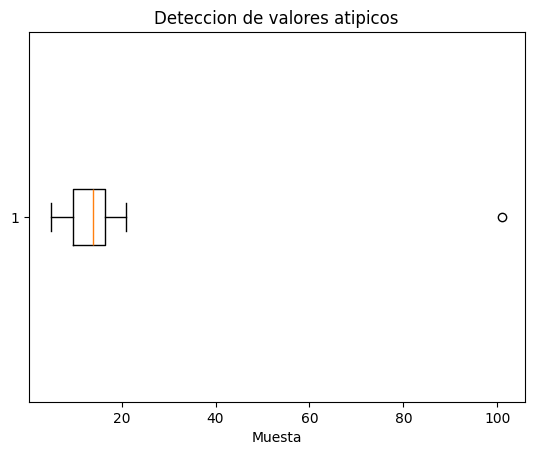

In [11]:
plt.boxplot(muestra, vert=False)
plt.title('Deteccion de valores atipicos')
plt.xlabel('Muesta')
plt.show();

### Puntuaicon Z

In [12]:
outliers = []

In [13]:
def encontrar_outliers(datos):
    umbral = 3 # Numero de desviacion estandar a superar
    media = np.mean(datos)
    desvstd = np.std(datos)
    for xi in datos:
        puntuaje_Z = (xi - media) / desvstd
        if (np.abs(puntuaje_Z) > umbral):
            outliers.append(xi)
    return media, desvstd, outliers

In [14]:
media, desviacion, extremos = encontrar_outliers(muestra)
print(f'La media de la distribucion es: {media:.2f}')
print(f'La desviacion de la distribucion es: {desviacion:.2f}')
print(f'Los valores extremos de la distribucion es: {extremos}')

La media de la distribucion es: 20.08
La desviacion de la distribucion es: 24.79
Los valores extremos de la distribucion es: [101]


# Deteccion de valores atipicos utilizando el rango Intercuartil (RIC)

In [15]:
outliers = []

In [18]:
def detectar_outliers_ric(datos):
    datos = sorted(datos)
    q1 = np.quantile(datos, 0.25)
    q3 = np.quantile(datos, 0.75)
    ric = q3 - q1
    li = q1 - 1.5*ric
    ls = q3 + 1.5*ric
    print(f'Limite inferior: {li}\nLimite superior: {ls}')
    for valor in datos:
        if (valor < li or valor > ls):
            outliers.append(valor)
    return outliers

In [20]:
extremos = detectar_outliers_ric(muestra)
print('Valores atipicos: ', extremos)

Limite inferior: -0.375
Limite superior: 26.625
Valores atipicos:  [101, 101]


### Recortar valores atìpicos

In [22]:
for i in extremos:
    temporal = np.delete(muestra, np.where(muestra == i))
    print('Lista con valores eliminados', temporal)
    

Lista con valores eliminados [15 18  7 13 16 11 21  5 15 10  9]
Lista con valores eliminados [15 18  7 13 16 11 21  5 15 10  9]
